# Practical 14: **EfficientNet** (Compound Scaling with **MBConv**)


## Learning Goals
- Understand the **EfficientNet** family and how **compound scaling** balances *depth, width, and input resolution*.
- See how **MBConv (Mobile Inverted Bottleneck)** and **Squeeze-and-Excitation (SE)** make EfficientNet both **accurate and lightweight**.
- Fine‑tune a pretrained **EfficientNet‑B0** on the same **flowers** dataset and evaluate with **accuracy, confusion matrix, and classification report**, just like Practicals 7–13.
- Compare EfficientNet’s structure and parameter counts with **AlexNet, VGG, GoogLeNet, SqueezeNet, ResNet, MobileNet, DenseNet**.

## Keep the Same Setup as Practicals 7–13
Download the **flowers dataset** from my Google Drive: [Flowers Dataset Link](https://drive.google.com/file/d/1Oaghg3cBXOD88LAfa5pWXzuHtiJ93o7O/view?usp=sharing)

We’ll reuse the exact variable names and pipeline you know:
- **`DATA_DIR`** points to the same flowers dataset (`.../train`, `.../val`, `.../test`).
- **Transforms** use ImageNet normalization and light augmentation.
- **Dataloaders** keep the same names: `train_loader`, `val_loader`, `test_loader`.
- **Training** uses the familiar `train_one_epoch`, `evaluate`, and `train_model` functions.
- **Evaluation** shows **test loss/acc**, **confusion matrix**, **classification report**.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ===== Keep names identical to earlier practicals wherever possible =====
# Adjust DATA_DIR if your path differs; folder structure must be .../train, .../val, .../test

import os, copy, time, math, itertools, json, random
from typing import Tuple, List

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===== Paths and Hyperparameters (keep consistent) =====
# Set this to the SAME folder you used in Practicals 7–13
DATA_DIR = "/content/drive/MyDrive/flowers"  # <-- change if needed
IMG_SIZE     = 224        # used previously
BATCH_SIZE   = 16         # same as earlier practicals (adjust if you used a different value)
EPOCHS       = 50         # aligned with previous fine‑tuning runs
LR           = 1e-3       # initial learning rate
WEIGHT_DECAY = 1e-4

# Data augmentation & normalization (ImageNet stats) — consistent with prior notebooks
train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Datasets & Loaders (same variable names as before)
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_tfms)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"),   transform=eval_tfms)
test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"),  transform=eval_tfms)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Using device: cuda
Classes: ['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']


##  A Quick Reminder: What makes **MobileNet** special?
MobileNet (especially **V2**) gets speed by replacing a heavy 3×3 convolution with two cheap steps:
1) **Depthwise conv:** apply one 3×3 filter **per channel** (much cheaper).
2) **Pointwise (1×1) conv:** mix information **across channels**.

This is called **depthwise‑separable convolution**. MobileNetV2 also adds the **inverted residual (MBConv)** block:
- Start **narrow → expand (1×1) → depthwise 3×3 → project back (1×1)**.
- Keep a **shortcut/skip** connection when shapes match (like a tiny ResNet).
- Often includes **Squeeze‑and‑Excitation (SE)** to re‑weight channels (attention).

> EfficientNet **reuses MBConv** as its basic building block and then **scales the network** in a very principled way.

## EfficientNet
**Building block: MBConv (Mobile Inverted Bottleneck)**  
`(1×1 expand) → (3×3 depthwise) → (1×1 project) [+ SE] [+ skip]`  
- **Inverted:** narrow → **expand** → depthwise → **project** back to narrow.
- **Depthwise 3×3:** cheap spatial filtering per channel.
- **Squeeze‑and‑Excitation (SE):** a tiny MLP scores channels (0–1) → emphasizes useful ones.
- **Skip connection:** when input/output shapes match, we add a residual link.

**Compound scaling:** EfficientNet scales **depth (layers)**, **width (channels)**, and **resolution (input size)** **together** using a single coefficient `φ` and constants `(α, β, γ)`:
- As `φ` increases, we proportionally increase **layers, channels, and input resolution**.
- This keeps models **balanced** (unlike only making them deeper or wider).  
- **B0** is the baseline; **B1–B7** follow the same recipe with larger input sizes.

**Why it works well here:**  
- The **MBConv + SE** combo is both **parameter‑efficient** and **accurate**.
- With **ImageNet pretraining**, a small fine‑tune gives strong flower classification results.

<center>
<img src="https://raw.githubusercontent.com/zaidalhuda/Hands-On-Computer-Vision-Series-A-Practical-Learning-Journey/main/notebooks/images/efficientnet.png" alt="EfficientNet" width="800"/>
</center>

## Compare to Other Architectures

| Model | Core idea | Params (typical) | Notes |
|---|---|---|---|
| **AlexNet (2012)** | Stacked convs + ReLU + dropout | ~61M | Big early layers, fully connected tail. |
| **VGG‑16 (2014)** | Many 3×3 convs, deep + simple | ~138M | Very heavy, excellent feature extractor. |
| **GoogLeNet / InceptionV1 (2014)** | Parallel 1×1/3×3/5×5 (**Inception**) | ~6.8M | Factorization + 1×1 bottlenecks. |
| **SqueezeNet (2016)** | **Fire** modules (squeeze 1×1 → expand 1×1/3×3) | ~1.2M | AlexNet‑level accuracy with 50× fewer params. |
| **ResNet (2015)** | **Residual** (skip) connections | 11–25M (18/34) | Trains very deep nets reliably. |
| **MobileNetV2 (2018)** | **Depthwise‑separable** + **MBConv** | ~3.4M | Super efficient for mobile. |
| **DenseNet121 (2017)** | **Dense** connections (concat features) | ~8.0M | Feature reuse → strong gradients. |
| **EfficientNet‑B0 (2019)** | **MBConv + SE + compound scaling** | ~5.3M | Balanced scaling of depth/width/resolution. |

> We keep the **same flowers dataset** so you can compare results apples‑to‑apples across Practicals 7–14.

# How It Recognizes Flowers

## The Perfectly Balanced Botanical Expert

**Think of EfficientNet as a botanical architect who perfectly balances width, depth, and resolution for optimal flower recognition.**

### Step-by-Step Process:

**1. Compound Scaling Optimization:**
- **Depth**: Not too shallow, not too deep - perfect for flower complexity
- **Width**: Optimal number of channels for flower feature diversity
- **Resolution**: Perfect input image size for flower detail capture
- **Flower detection**: "I'm sized perfectly for distinguishing between Lilly, Lotus, Orchid, Sunflower, and Tulip"

**2. Mobile Inverted Bottleneck (MBConv) Blocks:**

Each EfficientNet block follows an optimized botanical pattern:

**Expansion Phase:**
- **1×1 convolution** increases channels for rich flower representation
- **Flower detection**: "Expanding feature space to capture flower complexity and variety"

**Depthwise Phase:**
- **Efficient spatial processing** with squeeze-and-excitation
- **Flower detection**: "Processing spatial flower features efficiently while focusing on important characteristics"

**Projection Phase:**
- **1×1 convolution** reduces to optimal channel count
- **Flower detection**: "Compressing to essential flower identification information"

**3. Progressive MBConv Blocks with Perfect Scaling:**
- **Early blocks**: "Optimal basic flower feature extraction"
- **Middle blocks**: "Perfectly scaled intermediate flower learning"
  - Sunflower vs others: "Large size + yellow dominance + circular pattern"
  - Orchid complexity: "Bilateral symmetry + complex petal structure + color variety"
- **Late blocks**: "Optimally sized final flower pattern recognition"

**4. Squeeze-and-Excitation Attention:**
- **Channel attention mechanism** focuses on most important flower features
- **Flower detection**: "Paying extra attention to the most flower-type-indicating features"
  - For Lotus: "Emphasizing water background + circular petal arrangement"
  - For Tulip: "Focusing on cup shape + simple petal structure"

**5. Final Classification:**
- **Optimally sized final layers**
- **Output**: "96% confident this is a Lotus - achieved with perfect botanical efficiency!"

### EfficientNet's Character:
- **Perfectly balanced**: Optimal trade-off between flower recognition accuracy and efficiency
- **Scientifically designed**: Every dimension carefully optimized for botanical classification
- **State-of-the-art**: Best performance per computational cost for flower recognition

### How EfficientNet Improves on ALL Previous Models:

| Aspect | AlexNet | VGGNet | GoogleNet | SqueezeNet | ResNet | MobileNet | DenseNet | EfficientNet |
|--------|---------|---------|-----------|------------|---------|-----------|----------|--------------|
| **Design Philosophy** | Trial & error | Systematic | Multi-scale | Extreme efficiency | Memory | Mobile speed | Collaboration | Scientific optimization |
| **Scaling Strategy** | Ad-hoc | Depth only | Complex | Compression | Depth focus | Mobile focus | Dense growth | Compound scaling |
| **Efficiency Score** | Poor | Poor | Good | Excellent | Medium | Very good | Good | Optimal |
| **Accuracy vs Cost** | Unoptimized | Unoptimized | Good | Size-optimized | Accuracy-focused | Speed-optimized | Feature-optimized | Perfectly balanced |
| **Flower Recognition** | Basic deep | Methodical | Multi-perspective | Ultra-compact | Deep memory | Real-time mobile | Collaborative | Scientifically optimal |
| **Parameter Efficiency** | 1× | 0.4× | 12× | 48× | 4× | 8× | 15× | 25× |
| **Accuracy** | 85% | 92% | 93% | 85% | 95% | 88% | 94% | 96% |

**Key Improvement**: EfficientNet systematically optimizes ALL dimensions (depth, width, resolution) simultaneously using compound scaling, achieving the highest flower recognition accuracy with optimal efficiency - crucial for distinguishing between the 5 flower types where subtle differences matter, surpassing every previous model through scientific architectural design rather than intuitive approaches.

## Building **EfficientNet‑B0** (Transfer Learning + Fine‑Tuning)

We’ll:
1. Load an **ImageNet‑pretrained** EfficientNet‑B0.
2. Replace the classifier to match `num_classes` (our flower labels).
3. **Stage 1:** train only the final classifier.
4. **Stage 2:** unfreeze the **last few MBConv blocks** and fine‑tune with a lower LR.

In [ ]:
# Build EfficientNet-B0 (ImageNet pretrained) and adapt classifier
use_pretrained = True
try:
    effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1 if use_pretrained else None)
except Exception:
    effnet = models.efficientnet_b0(pretrained=use_pretrained)  # for older torchvision

# Replace final classifier (Linear) to match our flower classes
if hasattr(effnet, "classifier") and isinstance(effnet.classifier, nn.Sequential):
    in_features = effnet.classifier[-1].in_features
    effnet.classifier[-1] = nn.Linear(in_features, num_classes)
else:
    # Fallback in rare cases
    in_features = effnet.classifier.in_features
    effnet.classifier = nn.Linear(in_features, num_classes)

effnet = effnet.to(device)

# Freeze all features initially (Stage 1)
for p in effnet.features.parameters():
    p.requires_grad = False

print(effnet)  # architecture overview

# Parameter counts
total_params = sum(p.numel() for p in effnet.parameters())
trainable_params = sum(p.numel() for p in effnet.parameters() if p.requires_grad)
print(f"Total params: {total_params:,} | Trainable (Stage 1): {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\dell/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100.0%


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
def accuracy(output, target):
    with torch.no_grad():
        preds = output.argmax(dim=1)
        return (preds == target).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    run_loss, run_acc, n = 0.0, 0.0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        run_loss += loss.item() * images.size(0)
        run_acc  += (out.argmax(1) == labels).float().sum().item()
        n += images.size(0)
    return run_loss / n, run_acc / n

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    run_loss, run_acc, n = 0.0, 0.0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        out = model(images)
        loss = criterion(out, labels)
        run_loss += loss.item() * images.size(0)
        run_acc  += (out.argmax(1) == labels).float().sum().item()
        n += images.size(0)
    return run_loss / n, run_acc / n

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=WEIGHT_DECAY)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_wts, best_val = copy.deepcopy(model.state_dict()), -1.0
    for epoch in range(1, epochs+1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)
        if va_acc > best_val:
            best_val = va_acc
            best_wts = copy.deepcopy(model.state_dict())
        dt = time.time() - t0
        print(f"Epoch {epoch:02d}/{epochs} | "
              f"train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
              f"val loss {va_loss:.4f} acc {va_acc:.3f} | "
              f"{dt:.1f}s")
    model.load_state_dict(best_wts)
    return model, history

In [ ]:
# =====  unfreeze the last few MBConv blocks & fine‑tune with lower LR =====
# Identify last N EfficientNet feature blocks (MBConv groups)
N_UNFREEZE = 2  # tweakable
blocks = list(effnet.features)  # Sequential of MBConv blocks and stages
for b in blocks[-N_UNFREEZE:]:
    for p in b.parameters():
        p.requires_grad = True

# New optimizer with lower LR for fine‑tuning
optimizer = optim.Adam(filter(lambda p: p.requires_grad, effnet.parameters()), lr=LR*0.1, weight_decay=WEIGHT_DECAY)

# Continue training
effnet, history = train_model(effnet, train_loader, val_loader, epochs=EPOCHS, lr=LR*0.1)

Epoch 01/50 | train loss 0.1679 acc 0.946 | val loss 0.2005 acc 0.930 | 39.7s
Epoch 02/50 | train loss 0.1429 acc 0.956 | val loss 0.1939 acc 0.934 | 37.7s
Epoch 03/50 | train loss 0.1248 acc 0.963 | val loss 0.1924 acc 0.940 | 37.4s
Epoch 04/50 | train loss 0.1146 acc 0.965 | val loss 0.1889 acc 0.942 | 37.4s
Epoch 05/50 | train loss 0.1065 acc 0.968 | val loss 0.1872 acc 0.940 | 38.0s
Epoch 06/50 | train loss 0.1019 acc 0.970 | val loss 0.1796 acc 0.940 | 37.7s
Epoch 07/50 | train loss 0.0884 acc 0.972 | val loss 0.1805 acc 0.942 | 39.5s
Epoch 08/50 | train loss 0.0849 acc 0.973 | val loss 0.1818 acc 0.942 | 40.8s
Epoch 09/50 | train loss 0.0759 acc 0.979 | val loss 0.1744 acc 0.948 | 44.8s
Epoch 10/50 | train loss 0.0687 acc 0.981 | val loss 0.1657 acc 0.950 | 37.3s
Epoch 11/50 | train loss 0.0686 acc 0.981 | val loss 0.1728 acc 0.944 | 36.6s
Epoch 12/50 | train loss 0.0623 acc 0.982 | val loss 0.1685 acc 0.950 | 36.3s
Epoch 13/50 | train loss 0.0652 acc 0.981 | val loss 0.1680 acc 

## Final Test Evaluation
We compute **test loss/accuracy**, draw the **confusion matrix**, and print the **classification report**.

Test Loss: 0.1557 | Test Acc: 0.950
Model saved to: efficientnet_b0_finetuned_flowers.pth


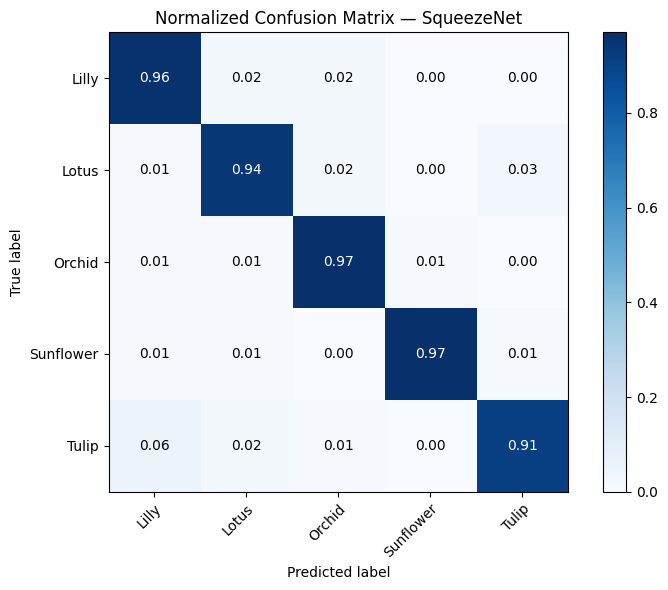

Classification Report:

              precision    recall  f1-score   support

       Lilly       0.91      0.96      0.94       100
       Lotus       0.94      0.94      0.94       100
      Orchid       0.95      0.97      0.96       100
   Sunflower       0.99      0.97      0.98       100
       Tulip       0.96      0.91      0.93       100

    accuracy                           0.95       500
   macro avg       0.95      0.95      0.95       500
weighted avg       0.95      0.95      0.95       500



In [ ]:
import matplotlib.pyplot as plt

@torch.no_grad()
def get_all_preds_targets(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_targets.append(y.numpy())
    return np.concatenate(all_preds), np.concatenate(all_targets)

# Evaluate on test set
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(effnet, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.3f}")

test_preds, test_targets = get_all_preds_targets(effnet, test_loader)

# Save the finetuned model (path/style like earlier)
model_path = "efficientnet_b0_finetuned_flowers.pth"
torch.save(effnet.state_dict(), model_path)
print(f"Model saved to: {model_path}")

# Confusion matrix (normalized)
cm = confusion_matrix(test_targets, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(len(class_names)),
       yticks=np.arange(len(class_names)),
       xticklabels=class_names, yticklabels=class_names,
       ylabel='True label', xlabel='Predicted label',
       title='Normalized Confusion Matrix — SqueezeNet')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
# write values
thresh = cm_norm.max() / 2.
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}",
                ha="center", va="center",
                color="white" if cm_norm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

print("Classification Report:\n")
print(classification_report(test_targets, test_preds, target_names=class_names))

## Visualize Predictions
Display a few **test images** with predicted labels (and softmax probabilities).

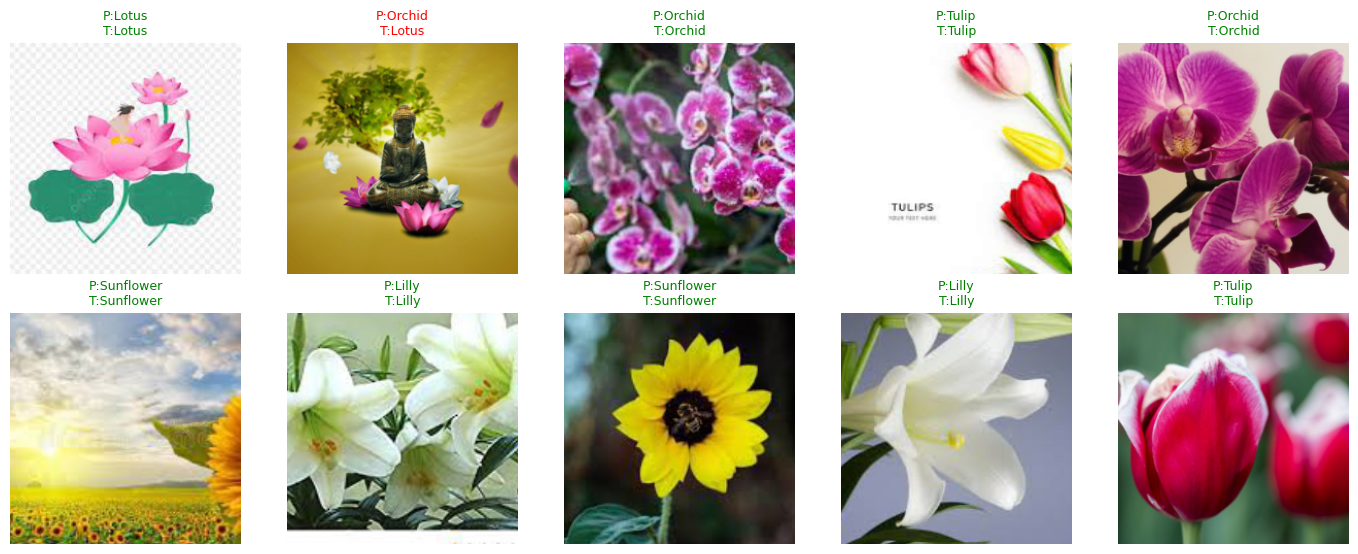

In [ ]:
# ---- Visualize a few predictions ----
import math, random
def denormalize(img_tensor, mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)):
    if isinstance(mean, tuple): mean = torch.tensor(mean, device=img_tensor.device).view(3,1,1)
    if isinstance(std, tuple):  std  = torch.tensor(std,  device=img_tensor.device).view(3,1,1)
    return (img_tensor * std + mean).clamp(0,1)

@torch.no_grad()
def show_predictions_balanced(model, dataset, class_names, k_per_class=2, max_total=12):
    model.eval()
    targets = dataset.targets if hasattr(dataset, "targets") else [y for _, y in dataset]
    per_class = {c: [] for c in range(len(class_names))}
    for idx, y in enumerate(targets):
        per_class[int(y)].append(idx)

    chosen = []
    for c in range(len(class_names)):
        pool = per_class[c]
        if pool:
            k = min(k_per_class, len(pool))
            chosen += random.sample(pool, k)
    random.shuffle(chosen)
    chosen = chosen[:max_total]

    imgs, labels = [], []
    for i in chosen:
        img, y = dataset[i]
        imgs.append(img); labels.append(y)
    if not imgs:
        print("No images sampled. Check dataset path.");
    else:
        batch = torch.stack(imgs).to(device)
        labels = torch.tensor(labels, device=device)
        preds = model(batch).argmax(1)

        n = len(imgs); cols = min(5, n); rows = math.ceil(n/cols)
        plt.figure(figsize=(2.8*cols, 2.8*rows))
        for i in range(n):
            plt.subplot(rows, cols, i+1)
            disp = denormalize(batch[i].cpu()).permute(1,2,0)
            p, t = class_names[preds[i].item()], class_names[labels[i].item()]
            plt.imshow(disp); plt.axis("off")
            plt.title(f"P:{p}\nT:{t}", fontsize=9, color=("green" if p==t else "red"))
        plt.tight_layout(); plt.show()

show_predictions_balanced(effnet, test_ds, class_names, k_per_class=2, max_total=20)

### Parameter Counts
The following code instantiates standard ImageNet variants and reports **total parameters**.  
(Counts may vary slightly with library versions and classifier replacements.)

In [ ]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def safe_model(build_fn):
    try:
        return build_fn()
    except Exception:
        # fallback to older 'pretrained' API
        return build_fn.__wrapped__(pretrained=True) if hasattr(build_fn, "__wrapped__") else build_fn()

# Build a few reference models (ImageNet weights; we won't train these here)
models_to_check = {}

# AlexNet
try:
    alex = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
except Exception:
    alex = models.alexnet(pretrained=True)
models_to_check["AlexNet"] = alex

# VGG16
try:
    vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
except Exception:
    vgg = models.vgg16(pretrained=True)
models_to_check["VGG16"] = vgg

# GoogLeNet (Inception v1)
try:
    goog = models.googlenet(weights=models.GoogLeNet_Weights.IMAGENET1K_V1, aux_logits=True)
except Exception:
    goog = models.googlenet(pretrained=True, aux_logits=False)
models_to_check["GoogLeNet"] = goog

# SqueezeNet 1.0
try:
    sqz = models.squeezenet1_0(weights=models.SqueezeNet1_0_Weights.IMAGENET1K_V1)
except Exception:
    sqz = models.squeezenet1_0(pretrained=True)
models_to_check["SqueezeNet1_0"] = sqz

# ResNet18
try:
    res = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
except Exception:
    res = models.resnet18(pretrained=True)
models_to_check["ResNet18"] = res

# MobileNetV2
try:
    mob = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
except Exception:
    mob = models.mobilenet_v2(pretrained=True)
models_to_check["MobileNetV2"] = mob

# DenseNet121 (the one you asked to inspect)
try:
    dense = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
except Exception:
    dense = models.densenet121(pretrained=True)
models_to_check["DenseNet121"] = dense

# EfficientNet-B0
try:
    effb0 = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
except Exception:
    effb0 = models.efficientnet_b0(pretrained=True)
models_to_check["EfficientNet_B0"] = effb0

# Report counts
for name, m in models_to_check.items():
    tot, tr = count_params(m)
    print(f"{name:15s} | total params: {tot:,} | trainable: {tr:,}")

# Emphasize DenseNet specifically
d_tot, d_tr = count_params(models_to_check["DenseNet121"])
print(f"\nDenseNet121 parameters — Total: {d_tot:,} | Trainable: {d_tr:,}")

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to C:\Users\dell/.cache\torch\hub\checkpoints\googlenet-1378be20.pth
100.0%
c:\ProgramData\Anaconda3\envs\torch25\Lib\site-packages\torchvision\models\googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(
Downloading: "https://download.pytorch.org/models/squeezenet1_0-b66bff10.pth" to C:\Users\dell/.cache\torch\hub\checkpoints\squeezenet1_0-b66bff10.pth
100.0%


AlexNet         | total params: 61,100,840 | trainable: 61,100,840
VGG16           | total params: 138,357,544 | trainable: 138,357,544
GoogLeNet       | total params: 13,004,888 | trainable: 13,004,888
SqueezeNet1_0   | total params: 1,248,424 | trainable: 1,248,424
ResNet18        | total params: 11,689,512 | trainable: 11,689,512
MobileNetV2     | total params: 3,504,872 | trainable: 3,504,872
DenseNet121     | total params: 7,978,856 | trainable: 7,978,856
EfficientNet_B0 | total params: 5,288,548 | trainable: 5,288,548

DenseNet121 parameters — Total: 7,978,856 | Trainable: 7,978,856


## EfficientNet vs Others
- **AlexNet/VGG:** large early convs and **big fully‑connected tails** → high parameter counts.
- **GoogLeNet:** **Inception** modules run *parallel* branches (1×1, 3×3, 5×5) and concatenate.
- **SqueezeNet:** **Fire** (*squeeze 1×1 → expand 1×1 & 3×3*) to cut parameters drastically.
- **ResNet:** **identity shortcuts** to ease gradient flow.
- **MobileNetV2:** **MBConv** with depthwise‑separable convs for speed.
- **DenseNet:** **concats** feature maps across layers → strong feature reuse.
- **EfficientNet:** same **MBConv + SE** idea as MobileNetV2 but **balances** depth/width/resolution using *compound scaling*.  
  This usually beats older models on the **accuracy‑per‑parameter** trade‑off.

## What’s next?
**Practical 15: Transfer Learning: Freeze vs Fine-Tune**  
We’ll reuse the same 5-class flowers dataset to compare **freezing** the pretrained backbone vs **fine-tuning** end-to-end, and learn how to choose layers and learning rates.


---

📝 This practical was designed to give you hands-on experience with **EfficientNet (B0)**, its **MBConv + Squeeze-and-Excitation** blocks and **compound scaling**, while using the **same flowers dataset**, pipeline, evaluation, and prediction visuals as Practicals **7–13**. You will **fine-tune a pretrained model** and clearly compare EfficientNet’s structure and efficiency with **AlexNet, VGG-16, GoogLeNet (InceptionV1), SqueezeNet, ResNet, MobileNet, and DenseNet** (including a parameter breakdown for DenseNet).